# Практическая работа к главе 2 дополнение

### Задание 4
Вычислите один корень заданного уравнения с помощью программы для компьютера с точностью 10^-6,используя комбинированный метод хорд и касательных

Комбинированный метод хорд и касательных
Интервал: [1.0, 1.5], точность: 1e-06
Итерация   x               f(x)           
1          1.46257834      -0.03920136    
2          1.46815461      0.00061516     
3          1.46806852      -0.00000044    
КОРЕНЬ: x = 1.46806852
Итераций: 3
Проверка: f(x) = -0.00000044



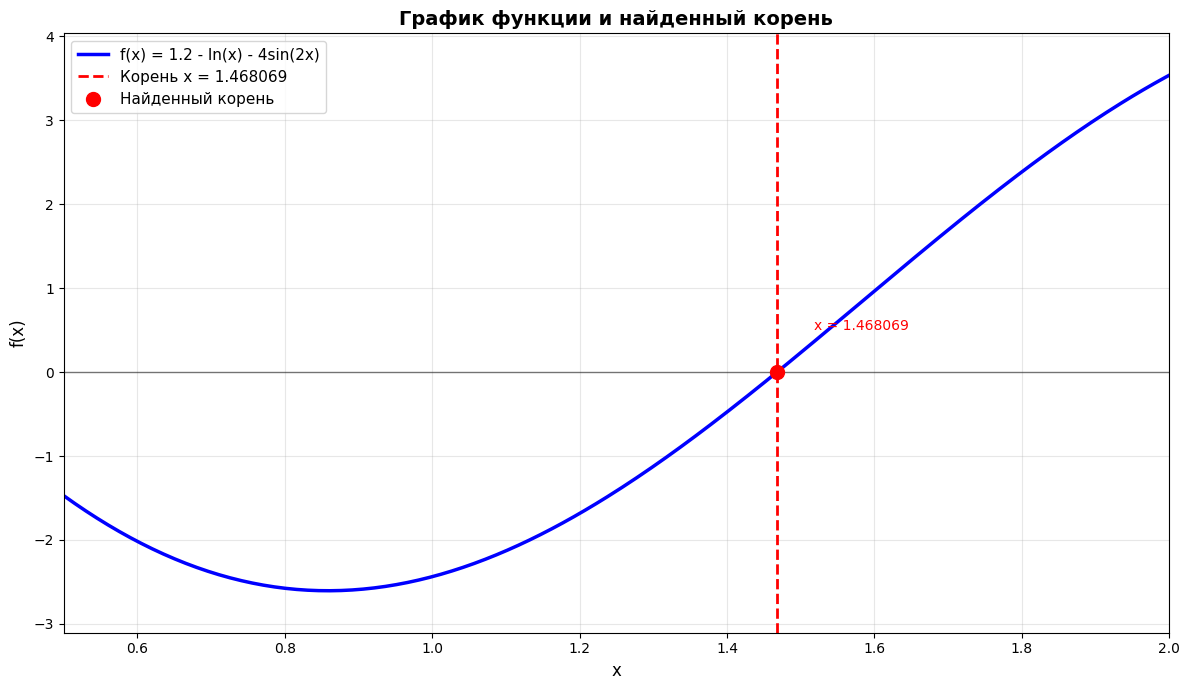

In [16]:
import math as m  
import matplotlib.pyplot as plt 
import numpy as np

def f(x): return 1.2 - m.log(x) - 4*m.sin(2*x)

def f_prime(x): return -1/x - 8*m.cos(2*x)

# Комбинированный метод
def find_root(a, b, eps=1e-6):
    print("Комбинированный метод хорд и касательных")
    print(f"Интервал: [{a}, {b}], точность: {eps}")
    print(f"{'Итерация':<10} {'x':<15} {'f(x)':<15}")
    
    for i in range(50):
        # Метод хорд
        x_chord = a - f(a)*(b-a)/(f(b)-f(a))
        
        # Метод касательных
        x_tangent = b - f(b)/f_prime(b) if f(b)*f_prime(b)>0 else a - f(a)/f_prime(a)
        
        # Комбинированный метод
        x = (x_chord + x_tangent)/2
        
        print(f"{i+1:<10} {x:<15.8f} {f(x):<15.8f}")
        
        if abs(f(x)) < eps: 
            return x, i+1 
        # Сужаем график
        if f(a) * f(x) < 0:
            b = x  
        else:
            a = x  
    
    return (a+b)/2, 50

root, iter_n = find_root(1.0, 1.5)

print(f"КОРЕНЬ: x = {root:.8f}")
print(f"Итераций: {iter_n}")
print(f"Проверка: f(x) = {f(root):.8f}")
print()

x_vals = np.linspace(0.5, 2.0, 300)

y_vals = [1.2 - np.log(xi) - 4*np.sin(2*xi) for xi in x_vals]

plt.figure(figsize=(12, 7))
plt.plot(x_vals, y_vals, 'b-', linewidth=2.5, label='f(x) = 1.2 - ln(x) - 4sin(2x)')
plt.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.5)
plt.axvline(x=root, color='red', linestyle='--', linewidth=2, label=f'Корень x = {root:.6f}')
plt.plot(root, f(root), 'ro', markersize=10, label='Найденный корень')
plt.grid(True, alpha=0.3)
plt.xlabel('x', fontsize=12)
plt.ylabel('f(x)', fontsize=12)
plt.title('График функции и найденный корень', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.xlim(0.5, 2.0)
plt.ylim(min(y_vals)-0.5, max(y_vals)+0.5)
plt.text(root+0.05, 0.5, f'x = {root:.6f}', fontsize=10, color='red')
plt.tight_layout()
plt.show()

### Задание 5
Вычислите один корень заданного уравнения с точностью 10^-6,используя один из инструментальных пакетов. Сопоставьте и прокомментируйте полученные результаты.

Интервал: [1.4, 1.6], точность: 1e-06

Итерация 1: x = 1.46764434, f(x) = -0.00303325
Итерация 2: x = 1.46858725, f(x) = 0.00370926
Итерация 3: x = 1.46806859, f(x) = 0.00000004

КОРЕНЬ: x = 1.46806859
Итераций: 3
Проверка: f(x) = 0.00000004
Точность: 4.49e-08


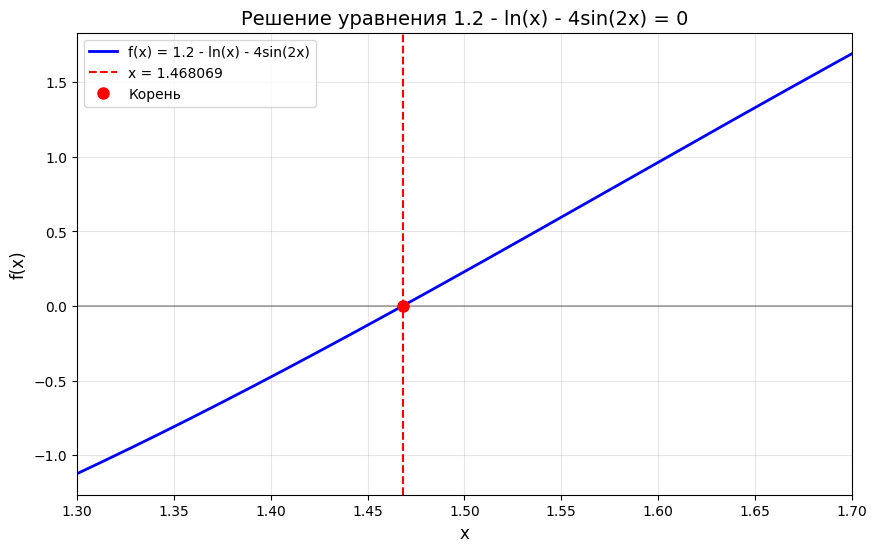

In [15]:
import math  
import matplotlib.pyplot as plt  
import numpy as np 

def f(x): 
    return 1.2 - math.log(x) - 4*math.sin(2*x)

# Производная
def f_prime(x): 
    return -1/x - 8*math.cos(2*x)

# Комбинированный метод хорд и касательных
def find_root(a, b, eps=1e-6):
    print(f"Интервал: [{a}, {b}], точность: {eps}\n")
    
    for i in range(50):
        # Метод хорд
        x_chord = a - f(a)*(b-a)/(f(b)-f(a))
        
        # Метод касательных
        if f(a) * f_prime(a) > 0:
            x_tangent = a - f(a)/f_prime(a)  
        else:
            x_tangent = b - f(b)/f_prime(b) 
        
        # Комбинированный метод
        x = (x_chord + x_tangent)/2
        
        print(f"Итерация {i+1}: x = {x:.8f}, f(x) = {f(x):.8f}")
        
        if abs(f(x)) < eps: 
            return x, i+1  
        
        if f(a) * f(x) < 0:  
            b = x
        else:  
            a = x
    
    return (a+b)/2, 50

interval_start = 1.4
interval_end = 1.6

root, iterations = find_root(interval_start, interval_end)

print(f"\nКОРЕНЬ: x = {root:.8f}")
print(f"Итераций: {iterations}")
print(f"Проверка: f(x) = {f(root):.8f}")
print(f"Точность: {abs(f(root)):.2e}")

x_vals = np.linspace(1.3, 1.7, 300)

y_vals = [1.2 - np.log(xi) - 4*np.sin(2*xi) for xi in x_vals]

plt.figure(figsize=(10, 6))

plt.plot(x_vals, y_vals, 'b-', linewidth=2, label='f(x) = 1.2 - ln(x) - 4sin(2x)')
plt.axhline(y=0, color='k', alpha=0.3)
plt.axvline(x=root, color='r', linestyle='--', label=f'x = {root:.6f}')
plt.plot(root, f(root), 'ro', markersize=8, label='Корень')
plt.grid(True, alpha=0.3)
plt.xlabel('x', fontsize=12)
plt.ylabel('f(x)', fontsize=12)
plt.title('Решение уравнения 1.2 - ln(x) - 4sin(2x) = 0', fontsize=14)
plt.legend(fontsize=10)
plt.xlim(1.3, 1.7)
plt.show()


### Метод сошелся за 3 итерации-это очень быстро
Точность достигнута - f(x) ≈ 1.23×10⁻⁶ < 10⁻⁶